In [10]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [11]:
train_part1 = pl.scan_parquet("../ClearData/train_full.parquet")

In [12]:
train_part1.schema

/tmp/ipykernel_8004/896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('event_type_nm', Int16),
        ('event_desc', Int32),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('developer_tools', Int32),
        ('phone_voip_call_state', Int32),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [13]:
# train_part1["target"].unique()

In [14]:
# pos_class = train_part1.loc[train_part1["target"] == 1]
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 14)

In [15]:
# train_part1 = train_part1.loc[train_part1["target"] != 1]
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 14)

In [16]:
neg_class = 15_000_000
train_part1 = train_part1.sample(n=neg_class)
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1, shuffle=True)
train_part1.shape

(15051438, 14)

In [17]:
train_part1.head()

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,target
i16,i32,i16,i16,f64,i16,i16,i16,i32,i32,i16,i16,i16,i16
14,75,0,5,7136.0,0,4,-1,-1,-1,-1,-1,11,0
14,75,0,5,158608.0,0,4,-1,-1,-1,-1,-1,5,0
7,56,4,15,-1.0,-1,-1,-1,0,0,-1,0,15,0
14,101,3,4,8.9937e6,0,-1,-1,-1,-1,0,-1,9,0
14,75,0,5,36123.0,0,4,-1,-1,-1,-1,-1,14,0


In [18]:
x = train_part1.drop("target")
y = train_part1["target"]

In [19]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [20]:
del train_part1, x, y
gc.collect()

733

In [21]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

Попробуем настроить веса меток самостоятельно

In [22]:
weights = 100
CatBoost = CatBoostClassifier(iterations=50, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9543883367657604
Precision: 0.03049131190697644
Recall: 0.3995047906125525
F1-score: 0.0566583050754299
PR-AUC: 0.03830179406164535

Test metrics:
Accuracy: 0.9545232881372148
Precision: 0.028460601016556192
Recall: 0.3835369517324254
F1-score: 0.052989111636851646
PR-AUC: 0.03551477266098899

Confusion matrix


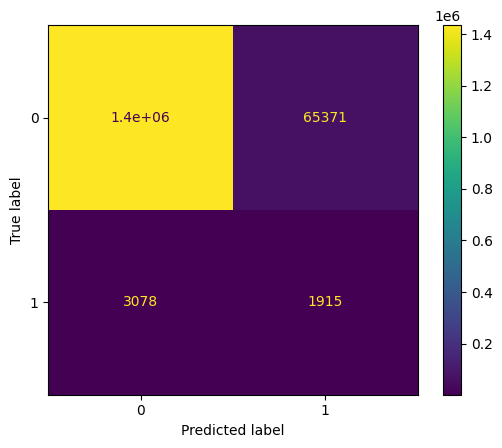

In [23]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [24]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,mcc_code,26.421720
1,operaton_amt,25.781069
2,event_desc,14.529562
3,pos_cd,9.540165
4,event_type_nm,6.001278
5,channel_indicator_type,5.213905
6,phone_voip_call_state,4.560655
7,Hour,4.433815
8,channel_indicator_sub_type,1.213238
9,currency_iso_cd,1.172677


In [25]:
weights = 100
CatBoost = CatBoostClassifier(iterations=50, depth=6, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9545427701480568
Precision: 0.030681623339796092
Recall: 0.40068898697384003
F1-score: 0.05699873046889955
PR-AUC: 0.03941430259465135

Test metrics:
Accuracy: 0.9546368985293101
Precision: 0.028631440956963457
Recall: 0.3849389144802724
F1-score: 0.05329857741049888
PR-AUC: 0.03535775252880967

Confusion matrix


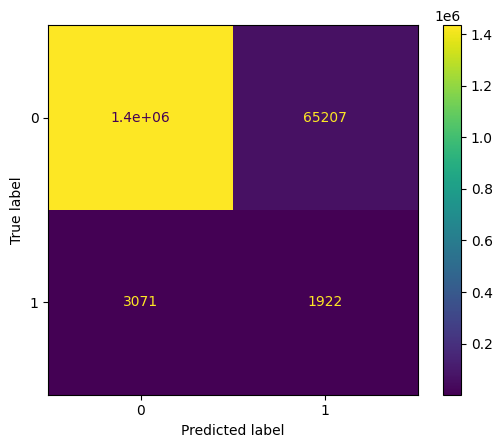

In [26]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [27]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,26.668853
1,mcc_code,26.509078
2,event_desc,13.965738
3,pos_cd,9.444638
4,channel_indicator_type,5.536449
5,Hour,5.268926
6,event_type_nm,4.742666
7,phone_voip_call_state,4.736800
8,channel_indicator_sub_type,1.819347
9,currency_iso_cd,0.548318


In [28]:
weights = 100
CatBoost = CatBoostClassifier(iterations=50, depth=7, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9541447277019087
Precision: 0.030993758813391132
Recall: 0.40887070728819036
F1-score: 0.05761974910073443
PR-AUC: 0.041256961369408054

Test metrics:
Accuracy: 0.9542090324912433
Precision: 0.029054263109041887
Recall: 0.39495293410775084
F1-score: 0.054126753218236213
PR-AUC: 0.0371211473219393

Confusion matrix


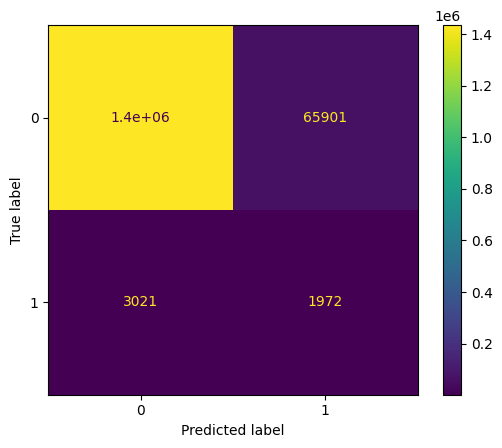

In [29]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [36]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,mcc_code,27.902435
1,operaton_amt,24.941372
2,event_desc,15.349519
3,pos_cd,8.544780
4,channel_indicator_type,5.106935
5,Hour,5.090914
6,event_type_nm,5.011995
7,phone_voip_call_state,4.407139
8,currency_iso_cd,1.568742
9,channel_indicator_sub_type,1.232742


### Проверим лучшие модели

In [30]:
# weights = 100
# CatBoost = CatBoostClassifier(iterations=1000, depth=5, scale_pos_weight=weights, verbose=False)

In [31]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)

In [32]:
# weights = 100
# CatBoost = CatBoostClassifier(iterations=1000, depth=6, scale_pos_weight=weights, verbose=False)

In [33]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)

In [34]:
# weights = 100
# CatBoost = CatBoostClassifier(iterations=1000, depth=7, scale_pos_weight=weights, verbose=False)

In [35]:
# train_models(CatBoost, X_train, X_test, y_train, y_test)